# Hypothesentest – einfach erklärt

> Quelle: [numiqo.de](https://numiqo.de/tutorial/hypothesentest)

**Hypothesentests** sind statistische Verfahren, mit denen du anhand von Stichprobendaten
Hypothesen über die **Grundgesamtheit** prüfen kannst.

**Wann wird ein Hypothesentest benötigt?**
Immer dann, wenn du mit einer **Stichprobe** eine Aussage über die **Grundgesamtheit**
treffen möchtest.

| Begriff | Bedeutung |
|---|---|
| **Signifikanzniveau α** | Max. akzeptierte Irrtumswahrscheinlichkeit (meist 5 %) |
| **p-Wert** | Wahrscheinlichkeit, das Ergebnis zu erhalten wenn H₀ gilt |
| **α-Fehler (Typ I)** | H₀ abgelehnt, obwohl sie wahr ist |
| **β-Fehler (Typ II)** | H₀ beibehalten, obwohl H₁ wahr ist |
| **Effektstärke** | Praktische Relevanz des Effekts (unabhängig von Signifikanz) |

> **Entscheidungsregel:** p < α → H₀ ablehnen | p ≥ α → H₀ nicht ablehnen

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats
from scipy.stats import norm as norm_dist

np.random.seed(42)
print("Bibliotheken erfolgreich geladen.")

Bibliotheken erfolgreich geladen.


## 1. Von der Stichprobe zur Grundgesamtheit

**Beispiel (numiqo):** Die Firma Müsli GmbH möchte wissen, ob ihre produzierten
Müsliriegel wirklich 250 g wiegen. Da es unmöglich ist, alle Riegel zu wiegen,
wird eine **Stichprobe** gezogen und ein Hypothesentest durchgeführt.

- **H₀:** Die Riegel wiegen im Durchschnitt 250 g (μ = 250)
- **H₁:** Die Riegel weichen vom Sollgewicht ab (μ ≠ 250)

> **Wichtig:** H₀ kann immer nur **abgelehnt** oder **nicht abgelehnt** werden –
> niemals „bewiesen" oder „bestätigt".

Stichprobe: Müsliriegel-Gewichte
n:             50
Sollgewicht:   250.0 g
Stichproben-MW:246.79 g
Stichproben-SD:4.20 g

Einstichproben t-Test
H0: mu = 250.0 g
H1: mu != 250.0 g  (zweiseitig)
t-Statistik: -5.4102
p-Wert:      0.0000

p=0.0000 < alpha=0.05 -> H0 wird ABGELEHNT
-> Die Riegel weichen signifikant vom Sollgewicht ab!


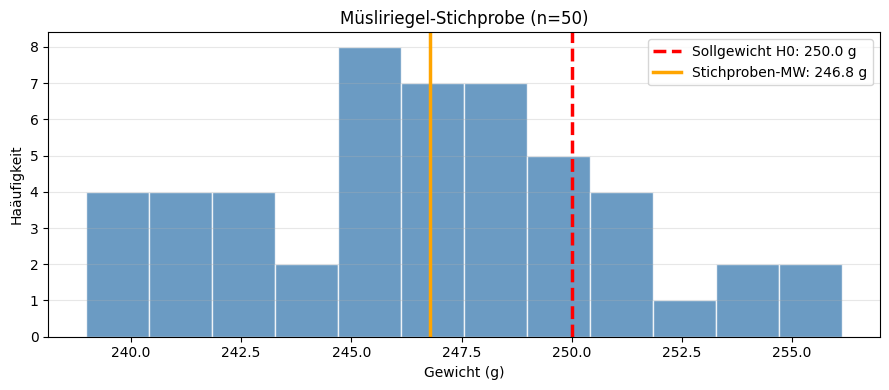

In [8]:
# Müsliriegel-Beispiel (numiqo)
np.random.seed(42)
n_riegel = 50
sollgewicht = 250.0

# Stichprobe: leicht unter Sollgewicht
gewichte = pd.Series(np.random.normal(loc=247.8, scale=4.5, size=n_riegel))

print("Stichprobe: Müsliriegel-Gewichte")
print(f"n:             {n_riegel}")
print(f"Sollgewicht:   {sollgewicht} g")
print(f"Stichproben-MW:{gewichte.mean():.2f} g")
print(f"Stichproben-SD:{gewichte.std():.2f} g")
print()

# Einstichproben t-Test
t_stat, p_wert = stats.ttest_1samp(gewichte, popmean=sollgewicht)

alpha = 0.05
print(f"Einstichproben t-Test")
print(f"H0: mu = {sollgewicht} g")
print(f"H1: mu != {sollgewicht} g  (zweiseitig)")
print(f"t-Statistik: {t_stat:.4f}")
print(f"p-Wert:      {p_wert:.4f}")
print()

if p_wert < alpha:
    print(f"p={p_wert:.4f} < alpha={alpha} -> H0 wird ABGELEHNT")
    print("-> Die Riegel weichen signifikant vom Sollgewicht ab!")
else:
    print(f"p={p_wert:.4f} >= alpha={alpha} -> H0 wird NICHT abgelehnt")
    print("-> Kein signifikanter Unterschied zum Sollgewicht nachweisbar.")

# Visualisierung
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(gewichte, bins=12, color="steelblue", edgecolor="white", alpha=0.8)
ax.axvline(sollgewicht, color="red",   linestyle="--", linewidth=2.5,
           label="Sollgewicht H0: " + str(sollgewicht) + " g")
ax.axvline(gewichte.mean(), color="orange", linestyle="-", linewidth=2.5,
           label="Stichproben-MW: " + str(round(gewichte.mean(), 1)) + " g")
ax.set_title("Müsliriegel-Stichprobe (n=" + str(n_riegel) + ")")
ax.set_xlabel("Gewicht (g)")
ax.set_ylabel("Haäufigkeit")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## 2. Signifikanzniveau α und p-Wert

Das **Signifikanzniveau α** wird **vor** der Untersuchung festgelegt und darf
danach nicht mehr geändert werden.

| α-Wert | Bezeichnung | Bedeutung |
|---|---|---|
| α ≤ 0,01 (1 %) | **hochsignifikant (h.s.)** | Sehr starke Evidenz gegen H₀ |
| α ≤ 0,05 (5 %) | **signifikant (s.)** | Ausreichende Evidenz gegen H₀ |
| α > 0,05 | **nicht signifikant (n.s.)** | Keine ausreichende Evidenz |

### Was bedeutet der p-Wert genau?

Der **p-Wert** gibt an: Wie wahrscheinlich ist es, das beobachtete Ergebnis
(oder ein noch extremeres) zu erhalten, **wenn H₀ tatsächlich wahr wäre**?

> Ein p-Wert von 0,04 bedeutet: Wenn H₀ gilt, gibt es nur 4 % Chance,
> diesen oder einen noch größeren Unterschied in der Stichprobe zu sehen.
> Da 4 % < 5 % (α), lehnen wir H₀ ab.

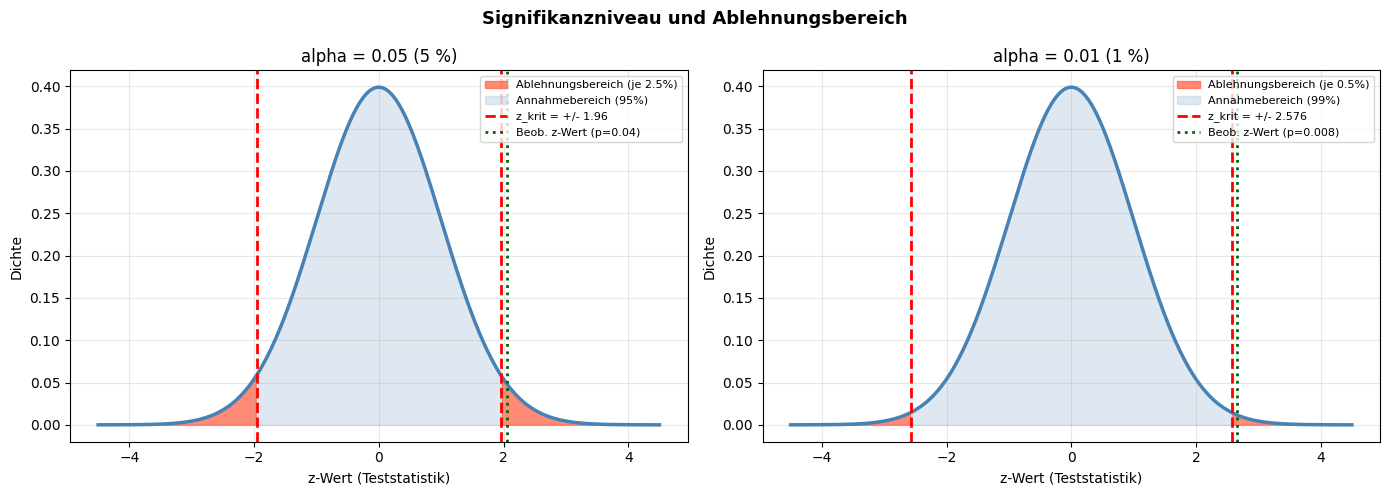

Signifikanzstufen:
  p <= 0.01 -> ** hochsignifikant
  p <= 0.05 -> *  signifikant
  p >  0.05 -> n.s. nicht signifikant


In [3]:
# Signifikanzniveau und Ablehnungsbereich visualisieren
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Signifikanzniveau und Ablehnungsbereich", fontsize=13, fontweight="bold")

x = np.linspace(-4.5, 4.5, 400)
y = norm_dist.pdf(x, 0, 1)

for ax, alpha_val, titel in zip(
    axes,
    [0.05, 0.01],
    ["alpha = 0.05 (5 %)", "alpha = 0.01 (1 %)"]
):
    z_krit = norm_dist.ppf(1 - alpha_val / 2)
    ax.plot(x, y, color="steelblue", linewidth=2.5)

    mask_r = x >= z_krit
    mask_l = x <= -z_krit
    ax.fill_between(x[mask_r], y[mask_r], color="tomato", alpha=0.75,
                    label="Ablehnungsbereich (je " + str(round(alpha_val/2*100, 1)) + "%)")
    ax.fill_between(x[mask_l], y[mask_l], color="tomato", alpha=0.75)
    ax.fill_between(x[~mask_r & ~mask_l], y[~mask_r & ~mask_l],
                    color="lightsteelblue", alpha=0.4,
                    label="Annahmebereich (" + str(round((1-alpha_val)*100)) + "%)")

    ax.axvline( z_krit, color="red", linestyle="--", linewidth=2)
    ax.axvline(-z_krit, color="red", linestyle="--", linewidth=2,
               label="z_krit = +/- " + str(round(z_krit, 3)))

    # p-Wert Beispiel einzeichnen
    p_bsp = 0.04 if alpha_val == 0.05 else 0.008
    z_bsp = norm_dist.ppf(1 - p_bsp/2)
    ax.axvline(z_bsp, color="darkgreen", linestyle=":", linewidth=2,
               label="Beob. z-Wert (p=" + str(p_bsp) + ")")

    ax.set_title(titel)
    ax.set_xlabel("z-Wert (Teststatistik)")
    ax.set_ylabel("Dichte")
    ax.legend(fontsize=8, loc="upper right")
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("Signifikanzstufen:")
print("  p <= 0.01 -> ** hochsignifikant")
print("  p <= 0.05 -> *  signifikant")
print("  p >  0.05 -> n.s. nicht signifikant")

## 3. Fehlerarten bei Hypothesentests

Bei jedem Hypothesentest können zwei Arten von Fehlern auftreten:

|  | **H₀ ist wahr** | **H₁ ist wahr** |
|---|---|---|
| **H₀ nicht ablehnen** | ✅ Richtige Entscheidung | ❌ **β-Fehler (Typ II)** |
| **H₀ ablehnen** | ❌ **α-Fehler (Typ I)** | ✅ Richtige Entscheidung |

### α-Fehler (Typ I) – Falsch-Positiv
- H₀ wird **abgelehnt**, obwohl sie wahr ist
- Wahrscheinlichkeit = α (Signifikanzniveau, z. B. 5 %)
- Kontrolle: α vor der Studie festlegen

### β-Fehler (Typ II) – Falsch-Negativ
- H₀ wird **nicht abgelehnt**, obwohl H₁ wahr ist
- Wahrscheinlichkeit = β
- **Teststärke (Power)** = 1 − β (Wahrscheinlichkeit, echten Effekt zu finden)

> **Tradeoff:** Senkt man α (weniger Typ-I-Fehler), steigt β (mehr Typ-II-Fehler).
> Mehr Stichprobengröße reduziert beide Fehler.

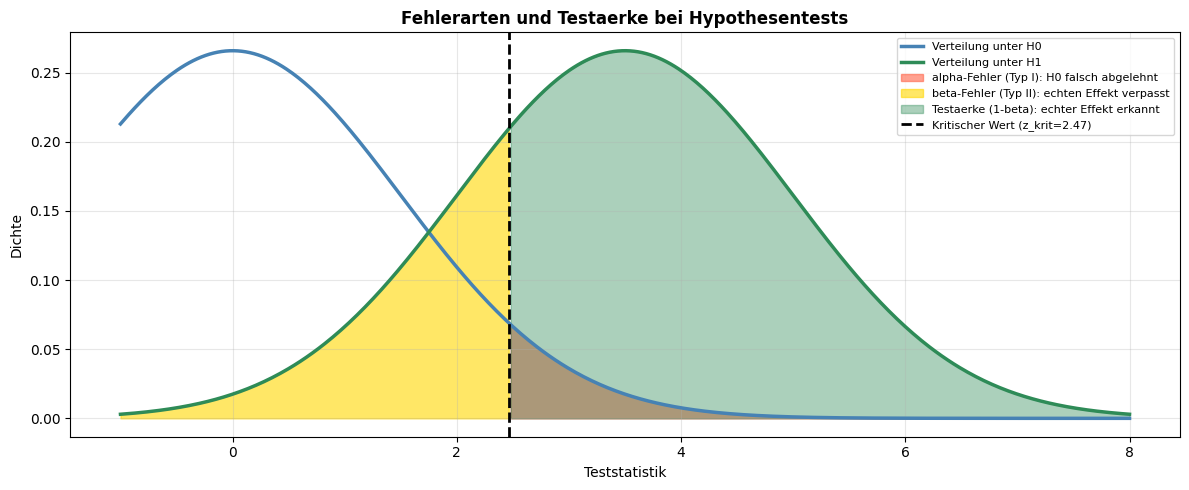

Fehlerarten (numerisch)
alpha (Typ-I-Fehler):    0.050  (5.0%)
beta  (Typ-II-Fehler):   0.246  (24.6%)
Testaerke (1-beta):      0.754  (75.4%)


In [9]:
# Fehlerarten visualisieren
fig, ax = plt.subplots(figsize=(12, 5))

x = np.linspace(-1, 8, 500)
mu_h0 = 0.0
mu_h1 = 3.5
sigma  = 1.5
alpha_v = 0.05
z_krit_v = norm_dist.ppf(1 - alpha_v) * sigma + mu_h0

y_h0 = norm_dist.pdf(x, mu_h0, sigma)
y_h1 = norm_dist.pdf(x, mu_h1, sigma)

ax.plot(x, y_h0, color="steelblue", linewidth=2.5, label="Verteilung unter H0")
ax.plot(x, y_h1, color="seagreen",  linewidth=2.5, label="Verteilung unter H1")

# Alpha-Fehler (rechts von z_krit unter H0)
mask_alpha = x >= z_krit_v
ax.fill_between(x[mask_alpha], y_h0[mask_alpha], color="tomato", alpha=0.6,
                label="alpha-Fehler (Typ I): H0 falsch abgelehnt")

# Beta-Fehler (links von z_krit unter H1)
mask_beta = x <= z_krit_v
ax.fill_between(x[mask_beta], y_h1[mask_beta], color="gold", alpha=0.6,
                label="beta-Fehler (Typ II): echten Effekt verpasst")

# Testaerke (rechts von z_krit unter H1)
mask_power = x >= z_krit_v
ax.fill_between(x[mask_power], y_h1[mask_power], color="seagreen", alpha=0.4,
                label="Testaerke (1-beta): echter Effekt erkannt")

ax.axvline(z_krit_v, color="black", linestyle="--", linewidth=2,
           label="Kritischer Wert (z_krit=" + str(round(z_krit_v, 2)) + ")")

ax.set_title("Fehlerarten und Testaerke bei Hypothesentests", fontsize=12, fontweight="bold")
ax.set_xlabel("Teststatistik")
ax.set_ylabel("Dichte")
ax.legend(fontsize=8, loc="upper right")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Berechnung
alpha_f    = norm_dist.sf(z_krit_v, mu_h0, sigma)
beta_f     = norm_dist.cdf(z_krit_v, mu_h1, sigma)
power_f    = 1 - beta_f
print("Fehlerarten (numerisch)")
print(f"alpha (Typ-I-Fehler):    {alpha_f:.3f}  ({alpha_f*100:.1f}%)")
print(f"beta  (Typ-II-Fehler):   {beta_f:.3f}  ({beta_f*100:.1f}%)")
print(f"Testaerke (1-beta):      {power_f:.3f}  ({power_f*100:.1f}%)")

## 4. Signifikanz vs. Effektstärke

**Statistisch signifikant ≠ praktisch relevant!**

Bei sehr großen Stichproben kann ein winziger, irrelevanter Unterschied
signifikant werden. Daher sollte immer auch die **Effektstärke** berichtet werden.

### Cohens d (für t-Tests)
$$d = \frac{\bar{x}_1 - \bar{x}_2}{s_{\text{pooled}}}$$

| d | Effektstärke |
|---|---|
| 0,2 | Klein |
| 0,5 | Mittel |
| 0,8 | Groß |

**Beispiel (numiqo):** Tiefkühlpizza-Hersteller – eine neue Verpackung steigert
die Verkaufszahlen signifikant (p < 0,05), aber nur um 2 Stück pro Monat.
Statistisch signifikant, aber wirtschaftlich irrelevant!

Fall 1: Grosse Stichprobe, kleiner Effekt
n=10000,  Differenz=2.8 Stueck
p-Wert:      0.000086  -> signifikant
Cohens d:    0.056  -> Effekt: vernachlaessigbar

Fall 2: Kleine Stichprobe, mittlerer Effekt
n=20,  Differenz=17.0 Punkte
p-Wert:      0.0024  -> signifikant
Cohens d:    1.030  -> Effekt: gross


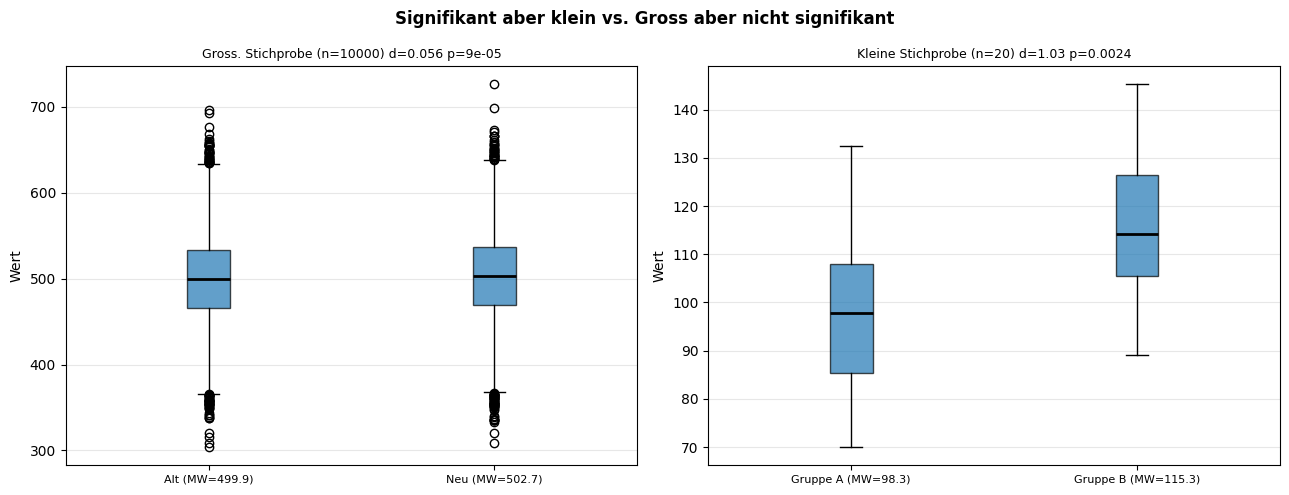

In [10]:
# Signifikanz vs. Effektstaerke – Demonstration
np.random.seed(42)

# Kleiner Effekt, riesige Stichprobe -> signifikant aber irrelevant
n_gross = 10000
pizza_alt = np.random.normal(500, 50, n_gross)
pizza_neu = np.random.normal(502, 50, n_gross)   # nur 2 Stueck Unterschied

# Mittlerer Effekt, kleine Stichprobe -> nicht signifikant
n_klein = 20
gruppe_a = np.random.normal(100, 15, n_klein)
gruppe_b = np.random.normal(112, 15, n_klein)    # 12 Punkte Unterschied

def cohens_d(x1, x2):
    n1, n2 = len(x1), len(x2)
    s_pool = np.sqrt(((n1-1)*np.std(x1, ddof=1)**2 +
                      (n2-1)*np.std(x2, ddof=1)**2) / (n1+n2-2))
    return (np.mean(x1) - np.mean(x2)) / s_pool

def interpret_d(d):
    d_abs = abs(d)
    if d_abs < 0.2:   return "vernachlaessigbar"
    elif d_abs < 0.5: return "klein"
    elif d_abs < 0.8: return "mittel"
    else:             return "gross"

t1, p1 = stats.ttest_ind(pizza_neu, pizza_alt)
t2, p2 = stats.ttest_ind(gruppe_b, gruppe_a)
d1 = cohens_d(pizza_neu, pizza_alt)
d2 = cohens_d(gruppe_b, gruppe_a)

print("Fall 1: Grosse Stichprobe, kleiner Effekt")
print(f"n={n_gross},  Differenz={pizza_neu.mean()-pizza_alt.mean():.1f} Stueck")
print(f"p-Wert:      {p1:.6f}  -> {'signifikant' if p1<0.05 else 'nicht signifikant'}")
print(f"Cohens d:    {d1:.3f}  -> Effekt: {interpret_d(d1)}")
print()
print("Fall 2: Kleine Stichprobe, mittlerer Effekt")
print(f"n={n_klein},  Differenz={gruppe_b.mean()-gruppe_a.mean():.1f} Punkte")
print(f"p-Wert:      {p2:.4f}  -> {'signifikant' if p2<0.05 else 'nicht signifikant'}")
print(f"Cohens d:    {d2:.3f}  -> Effekt: {interpret_d(d2)}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Signifikant aber klein vs. Gross aber nicht signifikant", fontsize=12, fontweight="bold")

for ax, d1_val, d2_val, titl, g1, g2, lab1, lab2 in [
    (axes[0], pizza_alt, pizza_neu, "Gross. Stichprobe (n=10000) d=" + str(round(d1,3)) + " p=" + str(round(p1,5)),
     pizza_alt, pizza_neu, "Alt (MW=" + str(round(pizza_alt.mean(),1)) + ")", "Neu (MW=" + str(round(pizza_neu.mean(),1)) + ")"),
    (axes[1], gruppe_a, gruppe_b, "Kleine Stichprobe (n=20) d=" + str(round(d2,3)) + " p=" + str(round(p2,4)),
     gruppe_a, gruppe_b, "Gruppe A (MW=" + str(round(gruppe_a.mean(),1)) + ")", "Gruppe B (MW=" + str(round(gruppe_b.mean(),1)) + ")")
]:
    ax.boxplot([g1, g2], patch_artist=True,
               medianprops=dict(color="black", linewidth=2),
               boxprops=dict(alpha=0.7))
    ax.set_xticklabels([lab1, lab2], fontsize=8)
    ax.set_title(titl, fontsize=9)
    ax.set_ylabel("Wert")
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Den passenden Hypothesentest finden

Die Wahl des Tests hängt vom **Skalenniveau** und der **Anzahl der Stichproben** ab.

### Übersicht (nach numiqo)

| Test | Skalenniveau | Stichproben |
|---|---|---|
| **Binomialtest** | 1× nominal | 1 Gruppe |
| **Chi-Quadrat-Test** | 1–2× nominal | Unabh. Gruppen |
| **Einstichproben t-Test** | 1× metrisch | vs. bekannten MW |
| **t-Test unabhängig** | 1× nominal (2 Gruppen) + 1× metrisch | 2 unabh. Gruppen |
| **t-Test abhängig** | 2× metrisch | Vorher-Nachher |
| **Mann-Whitney-U** | 1× nominal + 1× ordinal | 2 unabh. Gruppen |
| **Wilcoxon** | 2× ordinal | 2 abh. Gruppen |
| **ANOVA (einfaktoriell)** | 1× nominal (3+ Gruppen) + 1× metrisch | 3+ unabh. Gruppen |
| **Kruskal-Wallis** | 1× nominal (3+ Gruppen) + 1× ordinal | 3+ unabh. Gruppen |
| **Pearson-Korrelation** | 2× metrisch | Zusammenhang |
| **Spearman-Korrelation** | 2× ordinal | Zusammenhang |

In [12]:
# Drei numiqo-Beispiele aus dem Tutorial durchrechnen

print("Beispiel 1: t-Test unabhängig")
print("Einbrueche in Häusern MIT vs. OHNE Alarmanlage")

np.random.seed(1)
mit_alarm    = pd.Series(np.random.poisson(lam=1.2, size=60))
ohne_alarm   = pd.Series(np.random.poisson(lam=2.8, size=60))
t, p = stats.ttest_ind(mit_alarm, ohne_alarm)
print(f"MW mit Alarm:    {mit_alarm.mean():.2f}  |  MW ohne: {ohne_alarm.mean():.2f}")
print(f"t={t:.3f},  p={p:.6f}  -> {'signifikant ***' if p<0.001 else 'signifikant *' if p<0.05 else 'n.s.'}")

print()
print("Beispiel 2: t-Test abhängig (Vorher-Nachher)")
print("Blutdruck vor und nach Zigarettenkonsum")
np.random.seed(2)
n_vn = 40
vorher = pd.Series(np.random.normal(120, 10, n_vn))
nachher = vorher + np.random.normal(5, 4, n_vn)   # Blutdruck steigt
t2, p2 = stats.ttest_rel(vorher, nachher)
print(f"MW vorher: {vorher.mean():.1f} | MW nachher: {nachher.mean():.1f}")
print(f"t={t2:.3f},  p={p2:.6f}  -> {'signifikant ***' if p2<0.001 else 'signifikant *' if p2<0.05 else 'n.s.'}")

print()
print("Beispiel 3: Einfaktorielle ANOVA")
print("Gesundheitsbewusstsein: kleine / mittlere / grosse Staedte")
np.random.seed(3)
klein_stadt  = pd.Series(np.random.normal(62, 12, 50))
mittel_stadt = pd.Series(np.random.normal(67, 11, 50))
gross_stadt  = pd.Series(np.random.normal(74, 10, 50))
f_stat, p3 = stats.f_oneway(klein_stadt, mittel_stadt, gross_stadt)
print(f"MW klein={klein_stadt.mean():.1f} | mittel={mittel_stadt.mean():.1f} | gross={gross_stadt.mean():.1f}")
print(f"F={f_stat:.3f},  p={p3:.6f}  -> {'signifikant ***' if p3<0.001 else 'signifikant *' if p3<0.05 else 'n.s.'}")

Beispiel 1: t-Test unabhängig
Einbrueche in Häusern MIT vs. OHNE Alarmanlage
MW mit Alarm:    1.23  |  MW ohne: 2.97
t=-6.178,  p=0.000000  -> signifikant ***

Beispiel 2: t-Test abhängig (Vorher-Nachher)
Blutdruck vor und nach Zigarettenkonsum
MW vorher: 117.9 | MW nachher: 122.4
t=-6.834,  p=0.000000  -> signifikant ***

Beispiel 3: Einfaktorielle ANOVA
Gesundheitsbewusstsein: kleine / mittlere / grosse Staedte
MW klein=58.5 | mittel=67.8 | gross=74.3
F=26.687,  p=0.000000  -> signifikant ***


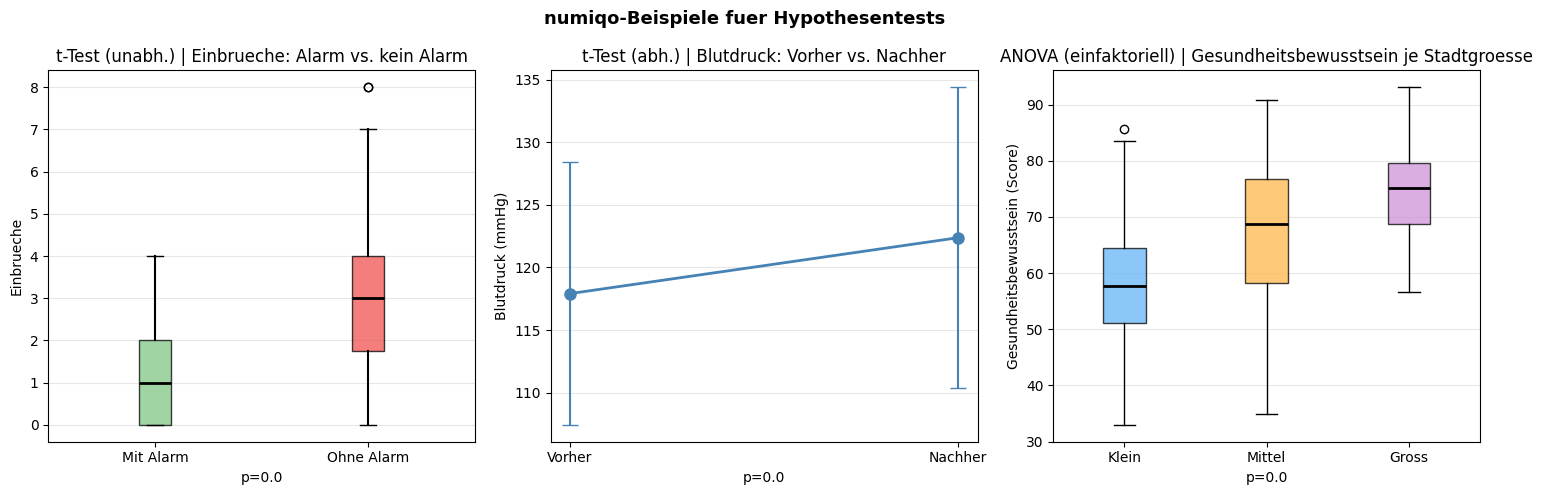

In [7]:
# Visualisierung aller drei numiqo-Beispiele
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("numiqo-Beispiele fuer Hypothesentests", fontsize=13, fontweight="bold")

# 1. t-Test unabhaengig
bp1 = axes[0].boxplot([mit_alarm, ohne_alarm], patch_artist=True,
                       medianprops=dict(color="black", linewidth=2),
                       whiskerprops=dict(linewidth=1.5))
for patch, fc in zip(bp1["boxes"], ["#81C784", "#EF5350"]):
    patch.set_facecolor(fc)
    patch.set_alpha(0.75)
axes[0].set_title("t-Test (unabh.) | Einbrueche: Alarm vs. kein Alarm")
axes[0].set_ylabel("Einbrueche")
axes[0].set_xticks([1, 2])
axes[0].set_xticklabels(["Mit Alarm", "Ohne Alarm"])
axes[0].set_xlabel("p=" + str(round(p, 6)))
axes[0].grid(axis="y", alpha=0.3)

# 2. t-Test abhaengig
axes[1].plot([1, 2], [vorher.mean(), nachher.mean()],
             "o-", color="steelblue", linewidth=2, markersize=8)
axes[1].errorbar([1], [vorher.mean()],  yerr=vorher.std(),
                 fmt="none", color="steelblue", capsize=6)
axes[1].errorbar([2], [nachher.mean()], yerr=nachher.std(),
                 fmt="none", color="steelblue", capsize=6)
axes[1].set_title("t-Test (abh.) | Blutdruck: Vorher vs. Nachher")
axes[1].set_ylabel("Blutdruck (mmHg)")
axes[1].set_xticks([1, 2])
axes[1].set_xticklabels(["Vorher", "Nachher"])
axes[1].set_xlabel("p=" + str(round(p2, 6)))
axes[1].grid(axis="y", alpha=0.3)

# 3. ANOVA
bp3 = axes[2].boxplot([klein_stadt, mittel_stadt, gross_stadt],
                       patch_artist=True,
                       medianprops=dict(color="black", linewidth=2))
farben_anova = ["#64B5F6", "#FFB74D", "#CE93D8"]
for patch, fc in zip(bp3["boxes"], farben_anova):
    patch.set_facecolor(fc)
    patch.set_alpha(0.75)
axes[2].set_title("ANOVA (einfaktoriell) | Gesundheitsbewusstsein je Stadtgroesse")
axes[2].set_ylabel("Gesundheitsbewusstsein (Score)")
axes[2].set_xticks([1, 2, 3])
axes[2].set_xticklabels(["Klein", "Mittel", "Gross"])
axes[2].set_xlabel("p=" + str(round(p3, 6)))
axes[2].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Zusammenfassung

```
Hypothesentest – Übersicht
│
├── ZIEL
│   Aussage ueber Grundgesamtheit auf Basis einer Stichprobe
│
├── GRUNDPRINZIP
│   ├── Immer H0 testen (kein Effekt / kein Unterschied)
│   ├── H0 kann nur ABGELEHNT oder NICHT ABGELEHNT werden
│   └── Nie: "H0 bewiesen" oder "H0 bestaetigt"
│
├── SIGNIFIKANZNIVEAU alpha
│   ├── VOR der Studie festlegen (meist 0.05)
│   ├── p < alpha  -> H0 ablehnen  (signifikant)
│   └── p >= alpha -> H0 nicht ablehnen (nicht signifikant)
│
├── SIGNIFIKANZSTUFEN
│   ├── p <= 0.01  -> ** hochsignifikant
│   ├── p <= 0.05  -> *  signifikant
│   └── p >  0.05  -> n.s. nicht signifikant
│
├── FEHLERARTEN
│   ├── alpha-Fehler (Typ I):  H0 abgelehnt obwohl wahr  (Falsch-Positiv)
│   ├── beta-Fehler (Typ II):  H0 behalten obwohl falsch (Falsch-Negativ)
│   └── Testaerke (Power) = 1 - beta
│
├── SIGNIFIKANZ vs. EFFEKTSTAERKE
│   ├── Signifikant != relevant
│   ├── Grosse Stichproben -> auch kleine Effekte signifikant
│   └── Cohens d: < 0.2 klein | 0.5 mittel | > 0.8 gross
│
└── TESTAUSWAHL (nach Skalenniveau)
    ├── Nominal:  Chi-Quadrat, Binomialtest
    ├── Ordinal:  Mann-Whitney, Wilcoxon, Kruskal-Wallis, Spearman
    └── Metrisch: t-Tests, ANOVA, Pearson
```

---
Quelle: [numiqo.de/tutorial/hypothesentest](https://numiqo.de/tutorial/hypothesentest)